<a href="https://colab.research.google.com/github/TheFinix13/NLP-coursework/blob/main/notebooks/2.2_RoBERTa_CrossVariety_Joel_Fiyin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
# Colab: clone + pip install. Private repo: Colab secret GITHUB_TOKEN (classic PAT, repo) + Notebook access on.

import os
import sys
import shutil
import subprocess

IN_COLAB = "COLAB_GPU" in os.environ or os.path.exists("/content")
REPO_DIR = os.environ.get("REPO_DIR", "/content/NLP-coursework")
REPO_SLUG = os.environ.get("GITHUB_REPO", "TheFinix13/NLP-coursework").strip().strip("/")
REPO_BRANCH = os.environ.get("REPO_BRANCH", "main").strip()
REPO_URL = os.environ.get("REPO_URL", "").strip()


def _token():
    t = os.environ.get("GITHUB_TOKEN", "").strip()
    if t:
        return t
    if not IN_COLAB:
        return ""
    try:
        from google.colab import userdata
        v = userdata.get("GITHUB_TOKEN")
        return "" if v is None else str(v).strip()
    except Exception:
        return ""


def _clone_url():
    if REPO_URL:
        return REPO_URL
    tok = _token()
    host = "github.com/" + REPO_SLUG + ".git"
    if tok:
        return "https://oauth2:" + tok + "@" + host
    return "https://" + host


def _is_repo_root(path):
    return bool(
        path
        and os.path.isdir(os.path.join(path, "src"))
        and os.path.isfile(os.path.join(path, "requirements.txt"))
    )


def _find_repo_under_content():
    base = "/content"
    if not os.path.isdir(base):
        return None
    for name in sorted(os.listdir(base)):
        p = os.path.join(base, name)
        if os.path.isdir(p) and _is_repo_root(p):
            return p
    return None


def _ensure_repo_colab():
    if _is_repo_root(REPO_DIR):
        return REPO_DIR

    zip_path = os.environ.get("REPO_ZIP", "/content/NLP-coursework.zip")
    if os.path.isfile(zip_path):
        subprocess.run(["unzip", "-q", "-o", zip_path, "-d", "/content"], check=False)

    found = _find_repo_under_content()
    if found:
        return found

    if os.path.isdir(REPO_DIR) and not _is_repo_root(REPO_DIR):
        shutil.rmtree(REPO_DIR, ignore_errors=True)

    CLONE_URL = _clone_url()
    cmd = ["git", "clone", "--depth", "1"]
    if REPO_BRANCH:
        cmd += ["--branch", REPO_BRANCH]
    cmd += [CLONE_URL, REPO_DIR]

    r = subprocess.run(cmd, capture_output=True, text=True)
    err = (r.stderr or r.stdout or "").strip()

    if r.returncode != 0 or not _is_repo_root(REPO_DIR):
        hint = ""
        if (
            "could not read Username" in err
            or "Authentication failed" in err
            or "403" in err
            or "Repository not found" in err
        ):
            hint = (
                "\nIf the repo is private: Colab → Secrets → GITHUB_TOKEN (repo scope) → enable Notebook access; "
                "Runtime → Restart, then re-run. Or upload NLP-coursework.zip to /content/.\n"
            )
        raise RuntimeError("Clone failed (need src/ + requirements.txt)." + hint + "\ngit said:\n" + err)
    return REPO_DIR


def _ensure_repo_local():
    cur = os.path.abspath(os.getcwd())
    for _ in range(10):
        if _is_repo_root(cur):
            return cur
        parent = os.path.dirname(cur)
        if parent == cur:
            break
        cur = parent
    raise RuntimeError("Run from repo root (contains src/ and requirements.txt).")


if IN_COLAB:
    root = _ensure_repo_colab()
    os.chdir(root)
    subprocess.run(
        [sys.executable, "-m", "pip", "-q", "install", "-r", "requirements.txt"],
        check=True,
    )
else:
    root = _ensure_repo_local()
    os.chdir(root)

os.environ["NLP_REPO_ROOT"] = os.path.abspath(root)
if root not in sys.path:
    sys.path.insert(0, root)
print("✅ Setup complete —", os.environ["NLP_REPO_ROOT"])



✅ Setup complete — /content/NLP-coursework


In [12]:
# Notebook run mode
# - DEMO_MODE=True: safe for "Runtime -> Run all" (fast, small subset)
# - DEMO_MODE=False: full experiment (slow; use GPU and expect long runtime)

import os

DEMO_MODE = os.environ.get("DEMO_MODE", "0") == "1"

# Common settings
TASK = os.environ.get("TASK", "sarcasm")  # sarcasm recommended for cross-variety
MODEL_NAME = os.environ.get("MODEL_NAME", "roberta-base")
MAX_LEN = int(os.environ.get("MAX_LEN", "128"))

# Demo defaults (fast)
if DEMO_MODE:
    SEEDS = [42]
    NUM_EPOCHS = 1
    TRAIN_BS = 8
    EVAL_BS = 16
    MAX_TRAIN_EX = 500
    MAX_VAL_EX = 200
    MAX_TEST_EX = 300
    MAX_TRAIN_CONDITIONS = 1
    MAX_TEST_SETS = 3
else:
    SEEDS = [42, 123]
    NUM_EPOCHS = 3
    TRAIN_BS = 16
    EVAL_BS = 32
    MAX_TRAIN_EX = None
    MAX_VAL_EX = None
    MAX_TEST_EX = None
    MAX_TRAIN_CONDITIONS = None
    MAX_TEST_SETS = None

print(
    "Mode:",
    "DEMO" if DEMO_MODE else "FULL",
    "| task=", TASK,
    "| model=", MODEL_NAME,
)


Mode: FULL | task= sarcasm | model= roberta-base


# Check dataset columns

In [13]:
import os
import sys

_MARK = ("src", "besstie_data_loader.py")


def _project_root():
    def ok(root):
        root = os.path.abspath(root)
        return os.path.isfile(os.path.join(root, *_MARK))

    r = os.environ.get("NLP_REPO_ROOT")
    if r and ok(r):
        return os.path.abspath(r)

    cur = os.path.abspath(os.getcwd())
    for _ in range(14):
        if ok(cur):
            return cur
        parent = os.path.dirname(cur)
        if parent == cur:
            break
        cur = parent

    hint = os.environ.get("NLP_REPO_ROOT", "")
    extra = ""
    if hint and os.path.isdir(os.path.join(hint, "src")) and not ok(hint):
        extra = (
            f"\n\nNLP_REPO_ROOT is set to {hint!r} but src/besstie_data_loader.py is missing.\n"
            "You may be on branch `main` (old layout) or an incomplete zip.\n"
            "Re-run setup with REPO_BRANCH=fiyin/model-pipeline or use a full zip from that branch."
        )
    raise RuntimeError(
        "Project root not found (need src/besstie_data_loader.py next to requirements.txt). "
        "Run the first setup cell, or set REPO_BRANCH=fiyin/model-pipeline and clone again."
        + extra
    )


PROJECT_ROOT = _project_root()
# Prepend so we beat any other `src` on Colab's path
while PROJECT_ROOT in sys.path:
    sys.path.remove(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)

from src.besstie_data_loader import load_besstie, get_train_conditions, get_test_conditions

ds = load_besstie()
print(ds["train"][0])



{'text': "I'm a member of the Green Party but I'll be voting Lib Dem as it's so tight here between Lib Dem and Tory. I cannot contemplate our useless tit of a Tory MP being reelected. I'll use the Swap My Vote website so someone somewhere can vote Green for me.", 'variety': 'en-UK', 'source': 'Reddit', 'Sentiment': 0.0, 'Sarcasm': 0.0}


In [14]:
from datasets import Dataset

from transformers import (
    RobertaForSequenceClassification,
    RobertaTokenizer,
    TrainingArguments,
    Trainer,
)

import torch
import numpy as np

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)

LABEL_COL = "Sarcasm" if TASK.lower() == "sarcasm" else "Sentiment"
TEXT_COL = "text"

tokenizer = RobertaTokenizer.from_pretrained(MODEL_NAME)

# Function to tokenize each batch of the dataset
def tokenize(batch):
    tokens = tokenizer(
        batch[TEXT_COL],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN,
    )
    tokens["labels"] = [int(label) for label in batch[LABEL_COL]]

    return tokens

def prepare_dataset(dataset):
    """Tokenizes and formats dataset for trainer"""

    tokenized = dataset.map(tokenize, batched=True)
    tokenized = tokenized.remove_columns(
        [c for c in tokenized.column_names if c not in
        ["input_ids", "attention_mask", "labels"]]
    )

    tokenized.set_format("torch")
    return tokenized

In [15]:
# Functions to compute model metrics
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
)


def compute_metrics(eval_pred):
    """Metrics used by Trainer during eval."""
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    return {
        "macro_f1": f1_score(labels, predictions, average="macro"),
        "accuracy": (predictions == labels).mean(),
    }


def _target_names(label_col: str):
    if label_col.lower() == "sarcasm":
        return ["Not Sarcastic", "Sarcastic"]
    if label_col.lower() == "sentiment":
        return ["Negative", "Positive"]
    return ["Class 0", "Class 1"]


def full_evaluation(y_true, y_pred, label_col: str):
    """Full metrics for report — called after training completes."""
    names = _target_names(label_col)
    return {
        "macro_f1": round(f1_score(y_true, y_pred, average="macro"), 4),
        "precision": round(precision_score(y_true, y_pred, average="macro"), 4),
        "recall": round(recall_score(y_true, y_pred, average="macro"), 4),
        "per_class_f1": f1_score(y_true, y_pred, average=None).tolist(),
        "confusion_matrix": confusion_matrix(y_true, y_pred).tolist(),
        "report": classification_report(y_true, y_pred, target_names=names),
    }

In [16]:
# Training function - using Trainer

def train_roberta(train_data, val_data, seed=42, output_dir="./tmp"):
    """Fine-tunes RoBERTa on given training data."""

    torch.manual_seed(seed)
    np.random.seed(seed)

    model = RobertaForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2,
    )

    # Tokenize training/validation
    train_tokenized = prepare_dataset(train_data)
    val_tokenized = prepare_dataset(val_data)

    import inspect

    eval_key = (
        "eval_strategy"
        if "eval_strategy" in inspect.signature(TrainingArguments.__init__).parameters
        else "evaluation_strategy"
    )

    args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=TRAIN_BS,
        per_device_eval_batch_size=EVAL_BS,
        learning_rate=2e-5,
        **{eval_key: "epoch"},
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        seed=seed,
        report_to="none",
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_tokenized,
        eval_dataset=val_tokenized,
        compute_metrics=compute_metrics,
    )

    trainer.train()
    return model, tokenizer

def evaluate_on_testset(model, test_data, label_col: str):
    """Runs trained model on a test set."""

    test_tokenized = prepare_dataset(test_data)

    trainer = Trainer(model=model)
    output = trainer.predict(test_tokenized)

    y_pred = np.argmax(output.predictions, axis=1)
    if output.label_ids is not None:
        y_true = np.asarray(output.label_ids).reshape(-1)
    else:
        y_true = np.asarray(test_tokenized["labels"])

    return full_evaluation(y_true, y_pred, label_col=label_col)

In [17]:
print("Train columns:", ds["train"].column_names)

Train columns: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm']


In [8]:
# Experiment loop
from tqdm import tqdm
import json

os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)

all_results = {}

train_conditions = get_train_conditions(ds)
test_sets = get_test_conditions(ds)
val_data = ds["validation"]

# DEMO_MODE: keep run-all fast + deterministic
if MAX_TRAIN_CONDITIONS is not None:
    train_conditions = dict(list(train_conditions.items())[:MAX_TRAIN_CONDITIONS])
if MAX_TEST_SETS is not None:
    test_sets = dict(list(test_sets.items())[:MAX_TEST_SETS])

if MAX_VAL_EX is not None:
    val_data = val_data.select(range(min(MAX_VAL_EX, len(val_data))))

print("Train conditions:", list(train_conditions.keys()))
print("Test sets:", list(test_sets.keys()))
print("Seeds:", SEEDS)

# Training conditions
for condition_name, train_data in tqdm(
    train_conditions.items(),
    desc="Conditions",
    position=0,
):
    if MAX_TRAIN_EX is not None:
        train_data = train_data.select(range(min(MAX_TRAIN_EX, len(train_data))))

    condition_results = {}

    # Loop for the seeds
    for seed in tqdm(
        SEEDS,
        desc=f" {condition_name}",
        position=1,
        leave=False,
    ):
        model, tok = train_roberta(
            train_data,
            val_data,
            seed=seed,
            output_dir=f"./tmp/{condition_name}_seed{seed}",
        )

        seed_results = {}
        for test_name, test_data in tqdm(
            test_sets.items(),
            desc=" Evaluating",
            position=2,
            leave=False,
        ):
            if MAX_TEST_EX is not None:
                test_data = test_data.select(range(min(MAX_TEST_EX, len(test_data))))

            results = evaluate_on_testset(model, test_data, label_col=LABEL_COL)
            seed_results[test_name] = results

        condition_results[f"seed_{seed}"] = seed_results

    averaged = {}

    for test_name in test_sets.keys():
        f1_scores = [
            condition_results[f"seed_{s}"][test_name]["macro_f1"]
            for s in SEEDS
        ]
        averaged[test_name] = {
            "macro_f1_mean": round(float(np.mean(f1_scores)), 4),
            "macro_f1_std": round(float(np.std(f1_scores)), 4),
        }

    all_results[condition_name] = {"by_seed": condition_results, "averaged": averaged}
    with open(f"results/{condition_name}.json", "w") as f:
        json.dump(all_results[condition_name], f, indent=2)


Filter:   0%|          | 0/3747 [00:00<?, ? examples/s]

Filter:   0%|          | 0/3747 [00:00<?, ? examples/s]

Filter:   0%|          | 0/3747 [00:00<?, ? examples/s]

Filter:   0%|          | 0/3747 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2183 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye



 Evaluating:  33%|███▎      | 1/3 [00:06<00:12,  6.03s/it]



 Evaluating:  67%|██████▋   | 2/3 [00:11<00:05,  5.88s/it]



 Evaluating: 100%|██████████| 3/3 [00:18<00:00,  6.42s/it]

                                                          
Conditions: 100%|██████████| 5/5 [50:38<00:00, 607.63s/it]


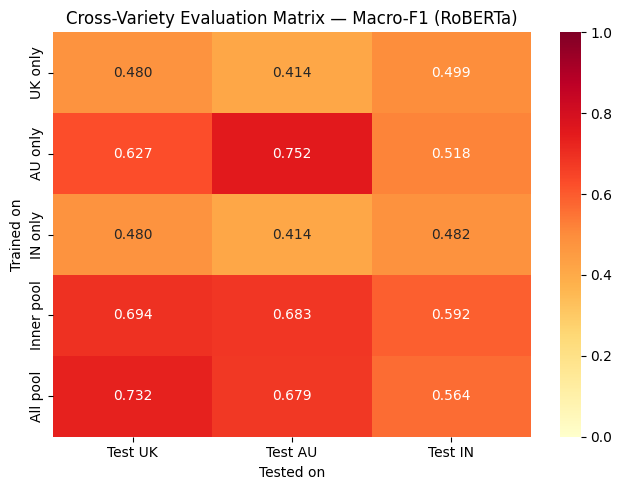


Cross-Variety Matrix:
            Test UK  Test AU  Test IN
UK only      0.4799   0.4139   0.4989
AU only      0.6272   0.7517   0.5178
IN only      0.4803   0.4139   0.4822
Inner pool   0.6935   0.6833   0.5917
All pool     0.7323   0.6787   0.5638


In [9]:
# Results Visualisation (incl cross variety matrix)

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

conditions = list(train_conditions.keys())
test_names = list(test_sets.keys())

_TRAIN_LABELS = {
    "uk_only": "UK only",
    "au_only": "AU only",
    "in_only": "IN only",
    "inner_pool": "Inner pool",
    "all": "All pool",
}
_TEST_LABELS = {
    "uk_test": "Test UK",
    "au_test": "Test AU",
    "in_test": "Test IN",
}
row_labels = [_TRAIN_LABELS.get(c, c) for c in conditions]
col_labels = [_TEST_LABELS.get(t, t) for t in test_names]

matrix = np.array([
    [all_results[c]["averaged"][t]["macro_f1_mean"] for t in test_names]
    for c in conditions
])

fig_h = max(4.0, 0.6 * len(conditions) + 2)
fig_w = max(6.0, 0.9 * len(test_names) + 4)
plt.figure(figsize=(fig_w, fig_h))

sns.heatmap(
    matrix,
    annot=True,
    fmt=".3f",
    xticklabels=col_labels,
    yticklabels=row_labels,
    cmap="YlOrRd",
    vmin=0.0,
    vmax=1.0,
)
plt.title("Cross-Variety Evaluation Matrix — Macro-F1 (RoBERTa)")
plt.ylabel("Trained on")
plt.xlabel("Tested on")
plt.tight_layout()
plt.savefig("figures/cross_variety_matrix.png", dpi=150)
plt.show()

results_df = pd.DataFrame(matrix, index=row_labels, columns=col_labels)
print("\nCross-Variety Matrix:")
print(results_df.to_string())

Best condition: all


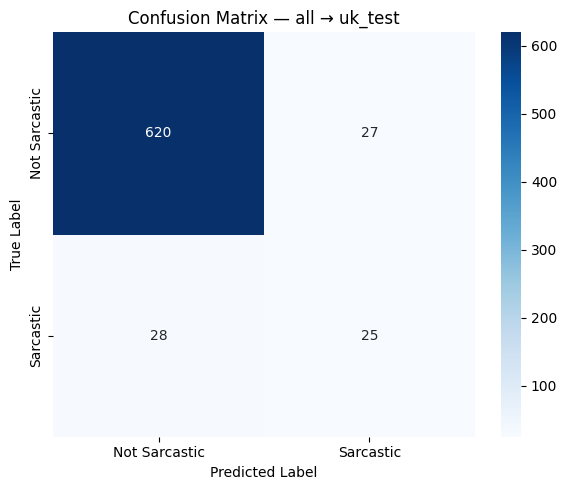

In [10]:
# Find confusion matrix for best conditions
best_condition = max(
    conditions,
    key=lambda c: np.mean([
        all_results[c]["averaged"][t]["macro_f1_mean"]
        for t in test_names
    ])
)
print(f"Best condition: {best_condition}")

_seed_key = f"seed_{SEEDS[0]}"
_cm_test = "uk_test" if "uk_test" in test_names else test_names[0]
best_cm = np.array(
    all_results[best_condition]["by_seed"][_seed_key][_cm_test]["confusion_matrix"]
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    best_cm,
    annot=True,
    fmt="d",
    xticklabels=["Not Sarcastic", "Sarcastic"],
    yticklabels=["Not Sarcastic", "Sarcastic"],
    cmap="Blues"
)
plt.title(f"Confusion Matrix — {best_condition} → {_cm_test}")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("figures/confusion_matrix_best.png", dpi=150)
plt.show()